# Manuscript 2 — Figure S7g and Figure 4g
### Sensory input fraction per cell type, and the wiring-diagram edge rules

**Fig. S7g** is the matrix of each ExN/PN cell type's mean sensory input composition, from
the per-neuron SPINE subtype predictions.

**Fig. 4g** is the summary wiring diagram. Its *node layout was drawn by hand in Illustrator*
and is not reproduced here — what this notebook regenerates is the part that is data-driven:
**which arrows are drawn, how thick each one is, and what colour it is**, from the
thresholds and bins given in the published legend. The resulting edge table is written to
`figure4_outputs/figure4g_wiring_edges.csv`.

### Inputs

| File | Used for |
| --- | --- |
| `data/sensory_input_features/projection_neuron.csv`, `excitatory_neurons.csv` | per-neuron SPINE sensory-input counts → S7g, and the sensory arrows of 4g |
| `figure4_outputs/celltype_avg_synapses_per_overlapping_pair.csv`, `celltype_mean_density_over_overlapping_pairs.csv` | ExN → ExN/PN arrows (written by `figure4bcf_S7abc_connectivity_matrices.ipynb`) |
| `figure4_outputs/sensory_avg_synapses_per_overlapping_pair.csv`, `sensory_mean_density_per_10um_overlap.csv` | sensory → ExN/PN arrows (written by `figureS7def_sensory_to_exn_matrices.ipynb`) |

> Run the other two Figure 4 notebooks first — this one reads the cell-type tables they save.

## 0) Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/sensory_input_features")
OUT_DIR = Path("figure4_outputs")
OUT_DIR.mkdir(exist_ok=True)

SENSORY_LABEL_MAP = {
    "C-Cold": "C-Cold",
    "Aδ-HTMR": "Aδ-HTMR",
    "C-HTMR": "C-HTMR/Heat (Sst+)",
    "C-HTMR-Non-peptidergic": "C-HTMR/Heat (MrgprA3/B4/D+)",
    "C-Heat": "Peptidergic C-fibers",
    "Aβ-LTMR": "Aβ-LTMR",
    "Aδ-LTMR": "Aδ-LTMR",
    "C-LTMR": "C-LTMR",
}
EXN_LABEL_MAP = {
    "p1": "P1", "p2_cold": "P2-cold", "p2_noci": "P2-noci", "p2_poly": "P2-poly",
    "v1": "V1", "v2": "V2", "r": "R",
    "noci_module": "Aδ-HTMR module",
    "np_module": "C-HTMR/Heat module",
    "cltmr_module": "C-LTMR module",
    "adltmr_module": "Aδ-LTMR module",
}

EXN_ORDER = ["p1", "p2_cold", "p2_noci", "p2_poly", "v1", "v2", "r",
             "noci_module", "np_module", "cltmr_module", "adltmr_module"]
SENSORY_ORDER = ["C-Cold", "Aδ-HTMR", "C-Heat", "C-HTMR",
                 "C-HTMR-Non-peptidergic", "C-LTMR", "Aδ-LTMR", "Aβ-LTMR"]

## 1) Per-neuron sensory input fractions

`sensory_cols` are the per-neuron counts of input synapses assigned to each sensory subtype
by SPINE. Two of the columns are not subtypes and matter for the denominator:

- `low_confidence_sensory` — a sensory input whose eight subtype probabilities were all ≤ 0.6
- `N/A` — input from a partner that is not a sensory afferent

Both stay in the total, so a fraction is *of all input synapses*, not of confidently-typed
sensory input only. They are dropped from the displayed columns.

In [2]:
pn = pd.read_csv(DATA_DIR / "projection_neuron.csv")
exn = pd.read_csv(DATA_DIR / "excitatory_neurons.csv")

sensory_cols = [
    "Aδ-HTMR", "C-Cold", "C-HTMR", "C-HTMR-Non-peptidergic", "C-Heat",
    "Aβ-LTMR", "Aδ-LTMR", "C-LTMR", "low_confidence_sensory", "N/A",
]

def calculate_sensory_fraction(df):
    frac_df = df.copy()
    total = frac_df[sensory_cols].sum(axis=1)
    frac_df[sensory_cols] = frac_df[sensory_cols].div(total, axis=0)
    return frac_df

def average_by_celltype(df):
    return df.groupby("cell_type")[sensory_cols].mean()

pn_type_fraction = average_by_celltype(calculate_sensory_fraction(pn))
exn_type_fraction = average_by_celltype(calculate_sensory_fraction(exn))

combined_fraction = pd.concat([pn_type_fraction, exn_type_fraction], axis=0)
plot_df = combined_fraction.reindex(index=EXN_ORDER, columns=SENSORY_ORDER)

print(f"{len(pn)} PN + {len(exn)} ExN")
print("\nMean fraction of total input synapses, by cell type:")
print(plot_df.round(3).to_string())

46 PN + 177 ExN

Mean fraction of total input synapses, by cell type:
               C-Cold  Aδ-HTMR  C-Heat  C-HTMR  C-HTMR-Non-peptidergic  C-LTMR  Aδ-LTMR  Aβ-LTMR
cell_type                                                                                       
p1              0.011    0.008   0.003   0.001                   0.000   0.001    0.000    0.000
p2_cold         0.352    0.016   0.045   0.001                   0.000   0.000    0.000    0.000
p2_noci         0.013    0.111   0.102   0.005                   0.001   0.000    0.000    0.000
p2_poly         0.039    0.025   0.053   0.005                   0.005   0.001    0.000    0.000
v1              0.001    0.007   0.002   0.001                   0.003   0.003    0.001    0.005
v2              0.001    0.018   0.004   0.002                   0.002   0.005    0.002    0.008
r               0.001    0.021   0.013   0.058                   0.054   0.010    0.005    0.005
noci_module     0.018    0.122   0.059   0.014           

## Figure S7g — sensory input fraction by cell type

Colour scale is fixed 0–50 %. Cells at or above the 3.5 % threshold are annotated; that same
threshold selects which sensory arrows appear in the wiring diagram below.

In [3]:
THRESHOLD = 0.035  # also the sensory-arrow cutoff for Fig. 4g

connections = [
    {"target": EXN_LABEL_MAP.get(t, t), "sensory": SENSORY_LABEL_MAP.get(s, s), "fraction": v}
    for t in plot_df.index for s in plot_df.columns
    if pd.notna(v := plot_df.loc[t, s]) and v >= THRESHOLD
]
connections_df = pd.DataFrame(connections).sort_values("fraction", ascending=False)
print(f"{len(connections_df)} (cell type, sensory subtype) pairs at or above {THRESHOLD:.1%}:")
print(connections_df.to_string(index=False))

13 (cell type, sensory subtype) pairs at or above 3.5%:
            target                     sensory  fraction
           P2-cold                      C-Cold  0.351615
C-HTMR/Heat module C-HTMR/Heat (MrgprA3/B4/D+)  0.239164
     C-LTMR module                      C-LTMR  0.202106
    Aδ-LTMR module                     Aδ-LTMR  0.137102
    Aδ-HTMR module                     Aδ-HTMR  0.122003
           P2-noci                     Aδ-HTMR  0.110897
           P2-noci        Peptidergic C-fibers  0.102460
    Aδ-HTMR module        Peptidergic C-fibers  0.058706
                 R          C-HTMR/Heat (Sst+)  0.057557
                 R C-HTMR/Heat (MrgprA3/B4/D+)  0.053869
           P2-poly        Peptidergic C-fibers  0.053422
           P2-cold        Peptidergic C-fibers  0.044788
           P2-poly                      C-Cold  0.038746


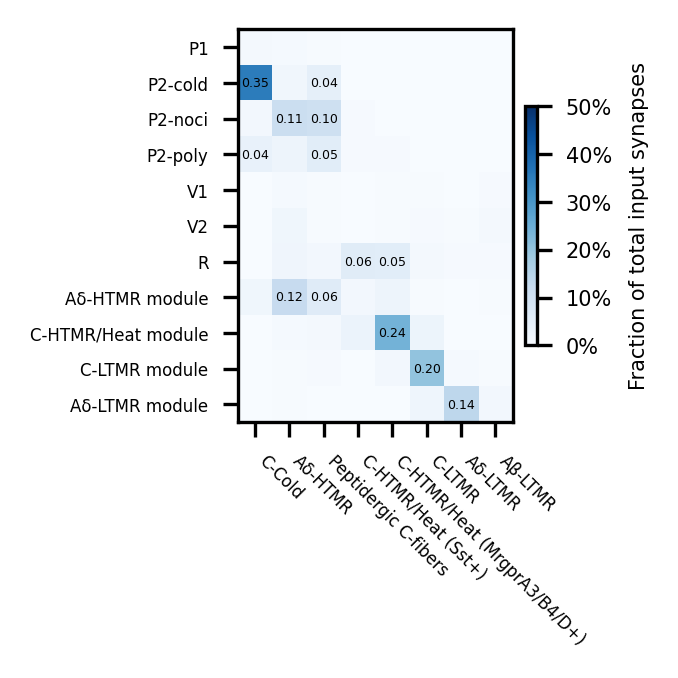

Saved: figure4_outputs/figureS7g_sensory_input_fraction_by_celltype.svg


In [4]:
fig, ax = plt.subplots(figsize=(6 / 2.54, 6 / 2.54), dpi=300)
im = ax.imshow(plot_df.values, cmap="Blues", vmin=0, vmax=0.5, aspect="auto")

ax.set_xticks(np.arange(len(plot_df.columns)))
ax.set_xticklabels([SENSORY_LABEL_MAP.get(x, x) for x in plot_df.columns],
                   rotation=-45, ha="left", fontsize=4)
ax.set_yticks(np.arange(len(plot_df.index)))
ax.set_yticklabels([EXN_LABEL_MAP.get(x, x) for x in plot_df.index], fontsize=4)

for i in range(plot_df.shape[0]):
    for j in range(plot_df.shape[1]):
        value = plot_df.iloc[i, j]
        if pd.notna(value) and value >= THRESHOLD:
            ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=3)

cbar = plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04)
cbar.set_label("Fraction of total input synapses", fontsize=5)
ticks = np.linspace(0, 0.5, 6)
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t * 100)}%" for t in ticks])
cbar.ax.tick_params(labelsize=5)

plt.tight_layout()
fig.savefig(OUT_DIR / "figureS7g_sensory_input_fraction_by_celltype.svg", bbox_inches="tight")
plt.show()
print("Saved:", OUT_DIR / "figureS7g_sensory_input_fraction_by_celltype.svg")

plot_df.to_csv(OUT_DIR / "celltype_sensory_input_fraction.csv")

## Figure 4g — wiring-diagram edge rules

An arrow is drawn for a (presynaptic type → postsynaptic type) pair when it passes the
anatomical density threshold, and — for the sensory arrows — when that sensory subtype also
supplies at least 3.5 % of the target type's input synapses.

Arrow **thickness** is binned on average synapses per overlapping pair and arrow **colour**
on synapse density, using exactly the bins printed in the published legend:

| Avg syn count | Thickness (pt) | | Normalized syn. density (syn/10 µm) | Colour |
| --- | --- | --- | --- | --- |
| < 0.25 | 0.5 | | < 0.036 | (not drawn) |
| 0.25 – 0.5 | 1 | | 0.036 – 0.07 | `#c9ddf0` |
| 0.5 – 1 | 2 | | 0.07 – 0.14 | `#77b5d9` |
| 1 – 2 | 4 | | > 0.14 | `#083e81` |
| 2 – 4 | 8 | | | |

(The density bin edges are `0.0036 / 0.007 / 0.014` synapses per µm, i.e. the legend's
per-10 µm values divided by 10.)

In [5]:
# six bins, matching the published size legend: <0.25 is below threshold and is
# drawn at the hairline width (those arrows are dashed, not solid coloured)
SIZE_BIN_EDGES = (0.25, 0.5, 1, 2, 4)
ARROW_SIZES_PTS = (0.3, 0.5, 1, 2, 4, 8)
AVG_THRESH = 0.25   # mean synapses per overlapping pair

DENS_THRESH = 0.0036                      # synapses per µm
COLOR_BIN_EDGES = (0.0036, 0.007, 0.014)  # synapses per µm
BIN_TO_HEX = {0: "#c9ddf0", 1: "#77b5d9", 2: "#083e81"}


def to_long(avg_df, dens_df, dens_is_per_10um=False):
    """Flatten a (pre type x post type) pair of matrices into a long edge table."""
    dens = dens_df / 10.0 if dens_is_per_10um else dens_df
    long = pd.DataFrame({
        "pre": np.repeat(avg_df.index, len(avg_df.columns)),
        "post": np.tile(avg_df.columns, len(avg_df.index)),
        "avg_syn_per_overlap_pair": avg_df.to_numpy().ravel(),
        "density_syn_per_um": dens.reindex(index=avg_df.index,
                                           columns=avg_df.columns).to_numpy().ravel(),
    })
    return long.dropna()


def assign_arrow_properties(df):
    """Add arrow thickness and colour columns following the published bins."""
    df = df.copy()

    size_idx = np.digitize(df["avg_syn_per_overlap_pair"], SIZE_BIN_EDGES, right=False)
    df["arrow_size_pts"] = np.asarray(ARROW_SIZES_PTS)[size_idx]

    dens_idx = np.clip(np.digitize(df["density_syn_per_um"], COLOR_BIN_EDGES, right=False) - 1, 0, 2)
    df["dens_bin"] = dens_idx
    df["dens_bin_value"] = np.asarray(COLOR_BIN_EDGES)[dens_idx]
    df["color_hex"] = [BIN_TO_HEX[int(x)] for x in dens_idx]
    return df

### Sensory afferent → ExN/PN arrows

Two filters, and a pair fails neither silently:

- **input-fraction filter** — the subtype supplies ≥ 3.5 % of the target type's input (Fig. S7g)
- **anatomical filter** — mean synapses per overlapping pair > 0.25 **and** density > 0.0036 syn/µm

A pair passing both is drawn as a **solid** arrow. A pair that passes the input-fraction
filter but fails the anatomical one is drawn **dashed** — the Methods note exactly three such
connections, which is what this reproduces.

One label alignment is needed first: the peptidergic C-fibre population is called
`Peptidergic C-Nociceptor` in the overlap tables and `Peptidergic C-fibers` in the SPINE
input-fraction table. They are the same neurons; without renaming, its four pairs silently
drop out of the merge and the dashed set comes out wrong.

In [6]:
sensory_avg = pd.read_csv(OUT_DIR / "sensory_avg_synapses_per_overlapping_pair.csv", index_col=0)
sensory_dens10 = pd.read_csv(OUT_DIR / "sensory_mean_density_per_10um_overlap.csv", index_col=0)

# same population, two different names across the two tables
LABEL_ALIGN = {"Peptidergic C-Nociceptor": "Peptidergic C-fibers"}
sensory_avg = sensory_avg.rename(index=LABEL_ALIGN)
sensory_dens10 = sensory_dens10.rename(index=LABEL_ALIGN)

sensory_long = to_long(sensory_avg, sensory_dens10, dens_is_per_10um=True)

# every pair passing the input-fraction filter is an arrow; whether it is solid
# or dashed depends on the anatomical filter
valid_pairs = connections_df.rename(columns={"target": "post", "sensory": "pre"})
sensory_edges = sensory_long.merge(valid_pairs, on=["pre", "post"], how="right")

assert sensory_edges[["avg_syn_per_overlap_pair", "density_syn_per_um"]].notna().all().all(), \
    "a sensory pair failed to match the overlap tables -- check LABEL_ALIGN"

solid = ((sensory_edges["avg_syn_per_overlap_pair"] > AVG_THRESH)
         & (sensory_edges["density_syn_per_um"] > DENS_THRESH))
sensory_edges["line_style"] = np.where(solid, "solid", "dashed")

sensory_edges = assign_arrow_properties(sensory_edges)
sensory_edges["edge_type"] = "sensory_to_celltype"
# a dashed arrow is below the anatomical threshold, so it carries no density colour
sensory_edges.loc[~solid, ["color_hex", "dens_bin", "dens_bin_value"]] = None

n_dashed = int((~solid).sum())
print(f"{len(sensory_edges)} sensory arrows: {int(solid.sum())} solid, {n_dashed} dashed")
assert n_dashed == 3, n_dashed  # Methods: three sub-threshold sensory connections drawn dashed
print(sensory_edges[["pre", "post", "avg_syn_per_overlap_pair", "density_syn_per_um",
                     "fraction", "line_style", "arrow_size_pts", "color_hex"]]
      .sort_values(["line_style", "post", "pre"]).to_string(index=False))

13 sensory arrows: 10 solid, 3 dashed
                        pre               post  avg_syn_per_overlap_pair  density_syn_per_um  fraction line_style  arrow_size_pts color_hex
       Peptidergic C-fibers            P2-cold                  0.050633            0.001047  0.044788     dashed             0.3      None
       Peptidergic C-fibers            P2-poly                  0.240000            0.003423  0.053422     dashed             0.3      None
C-HTMR/Heat (MrgprA3/B4/D+)                  R                  1.126404            0.002317  0.053869     dashed             2.0      None
                    Aδ-HTMR     Aδ-HTMR module                  2.222892            0.022176  0.122003      solid             4.0   #083e81
       Peptidergic C-fibers     Aδ-HTMR module                  1.153846            0.009079  0.058706      solid             2.0   #77b5d9
                    Aδ-LTMR     Aδ-LTMR module                 10.793333            0.047481  0.137102      solid         

### ExN → ExN/PN arrows

Both halves of the anatomical filter apply — mean synapses per overlapping pair > 0.25 **and**
density > 0.0036 syn/µm, as the Methods state. The sensory-input-fraction filter is specific
to the sensory arrows and is not applied here.

In [7]:
celltype_avg = pd.read_csv(OUT_DIR / "celltype_avg_synapses_per_overlapping_pair.csv", index_col=0)
celltype_dens = pd.read_csv(OUT_DIR / "celltype_mean_density_over_overlapping_pairs.csv", index_col=0)

celltype_long = to_long(celltype_avg, celltype_dens, dens_is_per_10um=False)
celltype_edges = assign_arrow_properties(
    celltype_long[(celltype_long["avg_syn_per_overlap_pair"] > AVG_THRESH)
                  & (celltype_long["density_syn_per_um"] >= DENS_THRESH)]
)
celltype_edges["edge_type"] = "celltype_to_celltype"
celltype_edges["line_style"] = "solid"
celltype_edges["pre"] = celltype_edges["pre"].map(lambda x: EXN_LABEL_MAP.get(x, x))
celltype_edges["post"] = celltype_edges["post"].map(lambda x: EXN_LABEL_MAP.get(x, x))

print(f"{len(celltype_edges)} ExN arrows")
print(celltype_edges[["pre", "post", "avg_syn_per_overlap_pair", "density_syn_per_um",
                      "arrow_size_pts", "color_hex"]].sort_values(["post", "pre"]).to_string(index=False))

18 ExN arrows
               pre          post  avg_syn_per_overlap_pair  density_syn_per_um  arrow_size_pts color_hex
    Aδ-LTMR module C-LTMR module                  3.901961            0.004947             4.0   #c9ddf0
                 R            P1                  0.656250            0.022114             1.0   #083e81
                V1            P1                  2.010471            0.038061             4.0   #083e81
                V2            P1                  0.299320            0.011090             0.5   #77b5d9
C-HTMR/Heat module       P2-noci                  0.449153            0.010060             0.5   #77b5d9
C-HTMR/Heat module       P2-poly                  0.432292            0.009163             0.5   #77b5d9
     C-LTMR module       P2-poly                  0.356725            0.005850             0.5   #c9ddf0
                V2       P2-poly                  0.310105            0.005351             0.5   #c9ddf0
C-HTMR/Heat module             R         

### The complete edge table

In [8]:
wiring_edges = (
    pd.concat([sensory_edges, celltype_edges], ignore_index=True)
    .sort_values(["edge_type", "post", "pre"])
    .reset_index(drop=True)
)[["edge_type", "pre", "post", "avg_syn_per_overlap_pair", "density_syn_per_um",
   "fraction", "line_style", "arrow_size_pts", "dens_bin", "dens_bin_value", "color_hex"]]

wiring_edges.to_csv(OUT_DIR / "figure4g_wiring_edges.csv", index=False)
print(f"{len(wiring_edges)} arrows written to", OUT_DIR / "figure4g_wiring_edges.csv")

# counted off the published panel export (one arrowhead per arrow)
PUBLISHED_ARROWS = {"#c9ddf0": 10, "#77b5d9": 10, "#083e81": 8}
solid_by_colour = wiring_edges[wiring_edges.line_style == "solid"].color_hex.value_counts().to_dict()
print("\nsolid arrows by colour  (published in parentheses):")
for colour, n_pub in PUBLISHED_ARROWS.items():
    print(f"   {colour}: {solid_by_colour.get(colour, 0):2d}  ({n_pub})")
assert solid_by_colour == PUBLISHED_ARROWS, solid_by_colour
assert int((wiring_edges.line_style == "dashed").sum()) == 3
print("\nmatches the published panel: 28 solid + 3 dashed")
print(wiring_edges.groupby(["line_style", "arrow_size_pts"]).size().to_string())

31 arrows written to figure4_outputs/figure4g_wiring_edges.csv

solid arrows by colour  (published in parentheses):
   #c9ddf0: 10  (10)
   #77b5d9: 10  (10)
   #083e81:  8  (8)

matches the published panel: 28 solid + 3 dashed
line_style  arrow_size_pts
dashed      0.3               2
            2.0               1
solid       0.5               7
            1.0               7
            2.0               7
            4.0               4
            8.0               3
